In [30]:
!pip install matplotlib
!pip install seaborn

sns.set_style("whitegrid")
import pandas as pd

df = pd.read_excel("cleaned_ecommerce_data.xlsx", engine="openpyxl")
df

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,calculated
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,No Coupon,Facebook,1325.06,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08,1050.08


# 1. Basic Understanding 

In [2]:
df.info

<bound method DataFrame.info of         OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0     ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1     ORD200001 2024-08-23     C75739    Phone         2     151.35   
2     ORD200002 2024-02-27     C81728   Tablet         5     550.68   
3     ORD200003 2023-10-15     C33540    Chair         1     273.19   
4     ORD200004 2025-05-08     C81840  Printer         4     626.01   
...         ...        ...        ...      ...       ...        ...   
1195  ORD201195 2024-06-20     C21126     Desk         1     107.04   
1196  ORD201196 2024-03-04     C20095  Monitor         2     662.53   
1197  ORD201197 2023-07-13     C79674   Tablet         2     436.84   
1198  ORD201198 2024-08-22     C64753    Chair         4     262.52   
1199  ORD201199 2023-06-11     C57502   Tablet         4     560.58   

     ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0        928 Main St    Debit Card   

In [9]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice,calculated
count,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558,819.856558


In [10]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
calculated         0
dtype: int64

# 2. Convert Date

In [33]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

# 3. Sales Analysis 

In [39]:
df['TotalPrice'].sum().round(2
                            )

np.float64(1264761.96)

In [46]:
df['TotalPrice'].mean().round(2)

np.float64(1053.97)

In [48]:
df['TotalPrice'].median()

823.615

In [49]:
df['TotalPrice'].max()

3456.4

In [50]:
df['TotalPrice'].min()

11.39

# 4. Sales trend over time 

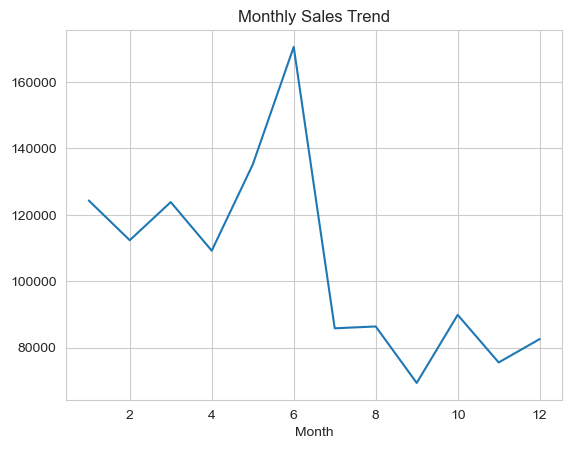

In [44]:
import matplotlib.pyplot as plt

df.groupby('Month')['TotalPrice'].sum().plot()
plt.title("Monthly Sales Trend")
plt.show()

# 5. Check distribution of sales

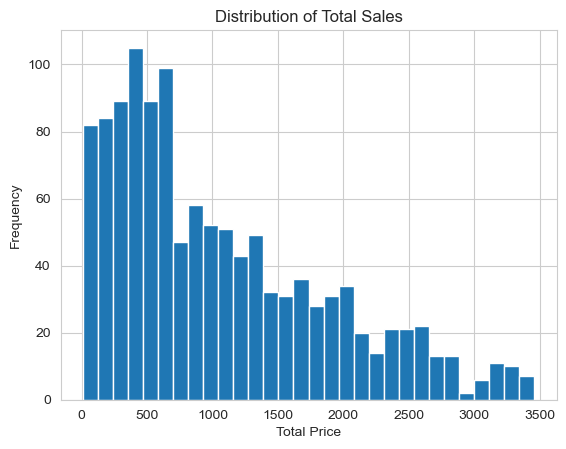

In [31]:
df['TotalPrice'].hist(bins=30)
plt.title("Distribution of Total Sales")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

# 6. Product Analysis

In [13]:
df['Product'].value_counts().head(10)

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [14]:
df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).head(10)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

## Top Product 

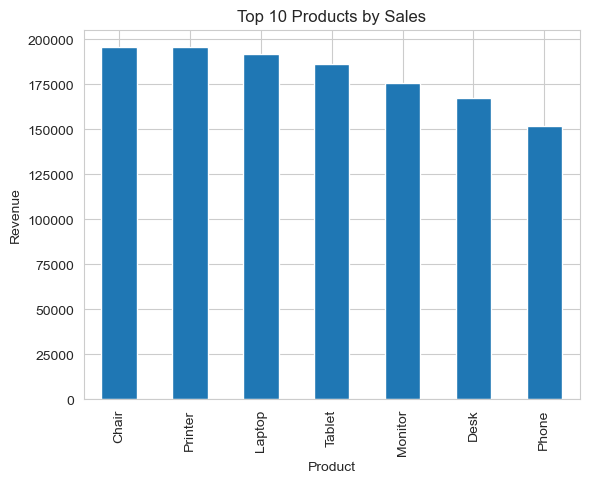

In [52]:
top_products = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

top_products.head(10).plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.ylabel("Revenue")
plt.show()

# 7. Customer Behaviour

In [15]:
df['CustomerID'].value_counts().head()

CustomerID
C38840    2
C14847    2
C21191    2
C94569    2
C46651    2
Name: count, dtype: int64

In [16]:
df['CustomerID'].value_counts().value_counts()

count
1    1178
2      11
Name: count, dtype: int64

# 8. Payment method analysis 

In [51]:
df['PaymentMethod'].value_counts()

df.groupby('PaymentMethod')['TotalPrice'].sum()

PaymentMethod
Cash           259786.29
Credit Card    263847.63
Debit Card     232361.18
Gift Card      246323.92
Online         262442.94
Name: TotalPrice, dtype: float64

# 9. Order status analysis 

In [21]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

# 10. Coupon Analysis 

In [22]:
df['CouponCode'].value_counts()

df.groupby('CouponCode')['TotalPrice'].mean()

CouponCode
FREESHIP     1070.405719
No Coupon    1043.370259
SAVE10       1065.874196
WINTER15     1035.902534
Name: TotalPrice, dtype: float64

# 11. Referral source analysis 

In [23]:
df['ReferralSource'].value_counts()

df.groupby('ReferralSource')['TotalPrice'].sum()

ReferralSource
Email        261808.55
Facebook     250410.90
Google       250441.48
Instagram    275285.45
Referral     226815.58
Name: TotalPrice, dtype: float64

# 12. Quantity & Pricing Analysis 

In [24]:
df[['Quantity', 'UnitPrice', 'TotalPrice']].describe()

,Quantity,UnitPrice,TotalPrice
count,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,1053.968300
std,1.407557,197.177146,819.856558
min,1.000000,11.390000,11.390000
25%,2.000000,186.062500,410.520000
50%,3.000000,364.210000,823.615000
75%,4.000000,521.570000,1578.475000
max,5.000000,699.930000,3456.400000


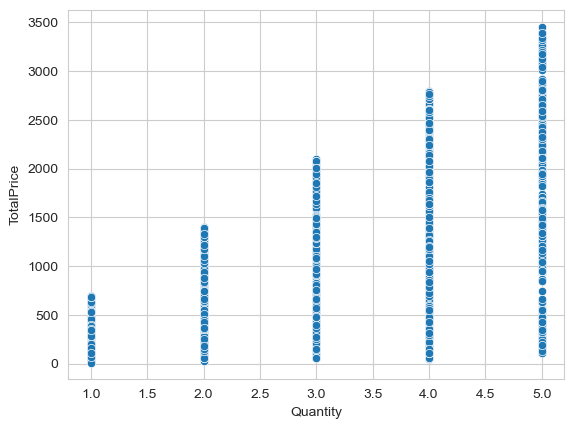

In [35]:
import seaborn as sns

sns.scatterplot(x='Quantity', y='TotalPrice', data=df)
plt.show()

# 13. Outlier Detection

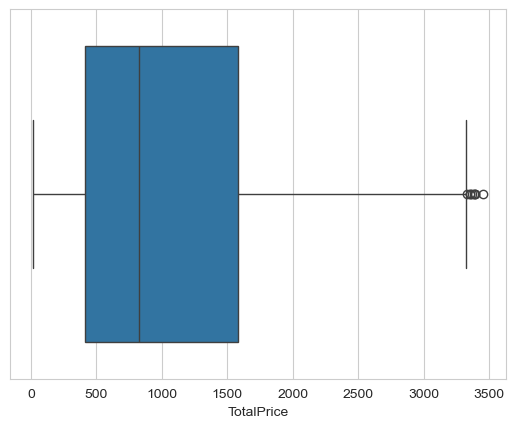

In [36]:
sns.boxplot(x=df['TotalPrice'])
plt.show()

# 14. Correlation

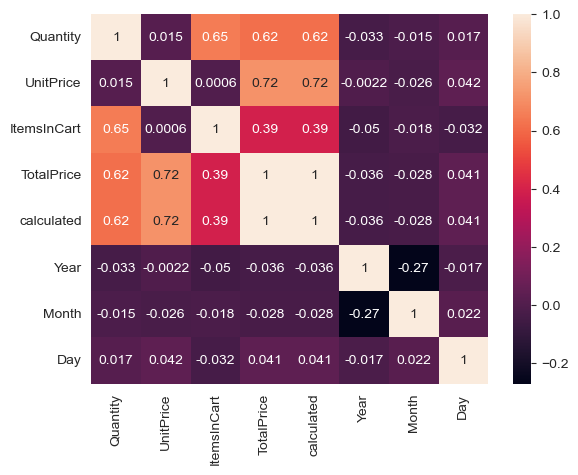

In [37]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# 15. Revenue by year 

<Axes: xlabel='ItemsInCart', ylabel='TotalPrice'>

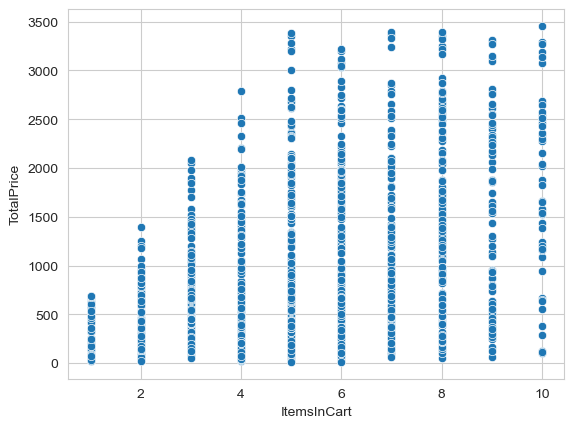

In [38]:
# Revenue by Year
df.groupby('Year')['TotalPrice'].sum()

# Items per order impact
sns.scatterplot(x='ItemsInCart', y='TotalPrice', data=df)